In [10]:
import pandas as pd
import pmdarima as pm

In [11]:
df_train = pd.read_csv('../data/processed/train, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv')
df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv')
df_train_decomposed = pd.read_csv('../data/processed/stl_decomposition/stl, train, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv')

Глубина 0
d = 0


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\pmdarima\utils\visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


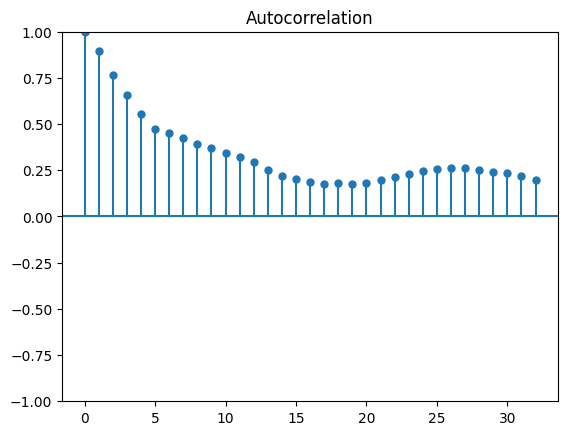

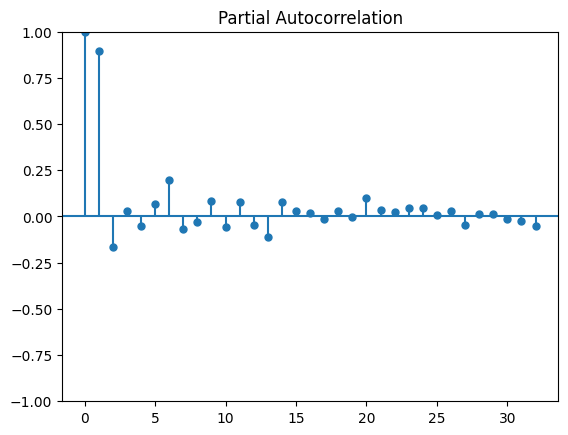

Глубина 5
d = 0


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\pmdarima\utils\visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


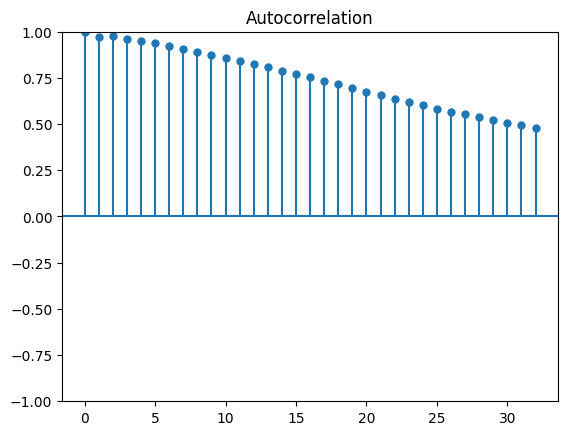

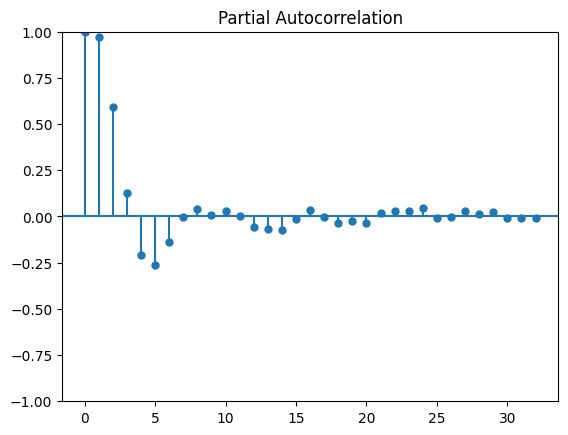

Глубина 10
d = 0


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\pmdarima\utils\visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


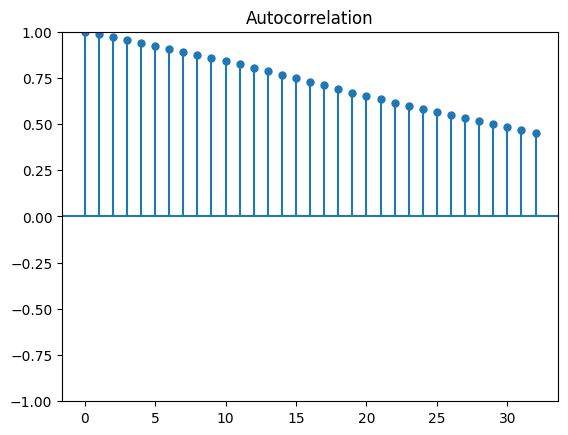

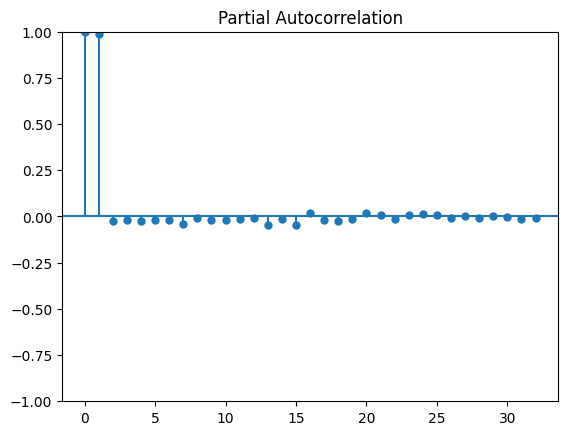

In [12]:
depths = [0,5,10]
for depth in depths:
    print(f'Глубина {depth}')
    train = df_train[f'48-1 ({depth})']

    seasonal = df_train_decomposed[f'48-1 ({depth}) seasonal']
    train_seasonless = train - seasonal

    d = pm.arima.ndiffs(train_seasonless, test='adf')
    print(f'd = {d}')
    if d > 0:
        train_seasonless = pm.utils.diff(train_seasonless, differences=d)

    pm.utils.plot_acf(train_seasonless)
    pm.utils.plot_pacf(train_seasonless)